In [1]:
# Cell 1: import + path + variabili configurabili
from __future__ import annotations

import logging
import os
import re
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from torch.utils.data import DataLoader


def find_repo_root(marker: str = 'config/default.yml', max_depth: int = 8) -> Path:
    root = Path.cwd().resolve()
    for _ in range(max_depth):
        if (root / marker).exists():
            return root
        root = root.parent
    raise FileNotFoundError(f'Cannot find repo root marker: {marker}')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

# Riuso codice esistente del modulo
from cyclone_locator import metrics as metrics_lib
from cyclone_locator.datasets.temporal_utils import TemporalWindowSelector
from cyclone_locator.datasets.windows_labeling import WindowsLabeling
from cyclone_locator.models.energy_fusion import compute_energy_features
import cyclone_locator.infer as infer_mod

# =======================
# INPUT PRINCIPALI
# =======================
CHECKPOINT_PATH = '/media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt'   # OBBLIGATORIO
CONFIG_YML = '/media/isacDisk1/Demetra/moduli/firstpass/config/config_exp31.yml'
MANIFEST_DATA = '/media/isacDisk1/Demetra/moduli/firstpass/manifests/all_data.csv'
PREDS_DATA = None  # se None e RUN_INFERENCE=True, viene calcolato nel notebook

OUTPUT_DIR = '/media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold'
LETTERBOX_META = '/media/isacDisk1/Demetra/moduli/firstpass/manifests/letterbox_meta.csv'  # opzionale
MEDICANES_WINDOWS_CSV = '/media/isacDisk1/Demetra/moduli/firstpass/mini_data_input/medicanes_new_windows.csv'

# Inference options
RUN_INFERENCE = True
BATCH_SIZE = 64
NUM_WORKERS = 40
DEVICE = 'cuda'            # 'cuda' / 'cpu' / None
INFER_THRESHOLD = None
INFER_SOFT_ARGMAX = True
INFER_SOFT_ARGMAX_TAU = None

# Fisso il mode richiesto: energy
PRESENCE_MODE = 'energy'

# Threshold analysis options
ID_COL = None              # es. 'event_id' / 'id_final'; None = auto-detect
NUM_THRESHOLDS = 201
MIN_SAMPLES = 1
TEMPORAL_T_OVERRIDE = None
TEMPORAL_STRIDE_OVERRIDE = None

print(f'[INFO] repo_root={REPO_ROOT}')
print(f'[INFO] presence_mode fixed: {PRESENCE_MODE}')




[INFO] repo_root=/media/isacDisk1/Demetra/moduli/firstpass
[INFO] presence_mode fixed: energy


In [2]:
# Cell 2: definizione funzioni

def resolve_path(path_str: Optional[str]) -> Optional[Path]:
    if path_str is None:
        return None
    txt = str(path_str).strip()
    if not txt:
        return None
    p = Path(txt).expanduser()
    if not p.is_absolute():
        p = (Path.cwd() / p).resolve()
    return p


def normalize_path(path_str: str, base_dir: Path) -> str:
    p = str(path_str).strip()
    if not p or p.lower() == 'nan':
        return ''
    pp = Path(p)
    if pp.is_absolute():
        return str(pp.resolve())
    return str((base_dir / pp).resolve())


def load_cfg(cfg_path: Path) -> dict:
    with open(cfg_path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def detect_id_col(df: pd.DataFrame, forced: Optional[str] = None) -> str:
    if forced is not None:
        if forced not in df.columns:
            raise ValueError(f'Forced id column not found: {forced}. Available: {list(df.columns)}')
        return forced

    detected = WindowsLabeling._detect_event_id_column(df)  # riuso funzione esistente
    if detected is not None:
        return detected

    if 'event_ids' in df.columns:
        return 'event_ids'

    raise ValueError(f'No cyclone/event id column found. Available columns: {list(df.columns)}')


def normalize_event_id(value) -> Optional[str]:
    return WindowsLabeling._normalize_event_id(value)  # riuso funzione esistente


def prob_to_logit(prob: float, eps: float = 1e-6) -> float:
    p = float(np.clip(float(prob), eps, 1.0 - eps))
    return float(np.log(p / (1.0 - p)))


def load_windows_boundaries(windows_csv: Optional[Path]) -> Dict[str, Tuple[pd.Timestamp, pd.Timestamp]]:
    if windows_csv is None:
        return {}
    if not windows_csv.exists():
        raise FileNotFoundError(f'Windows CSV not found: {windows_csv}')

    wdf = pd.read_csv(windows_csv)
    if 'start_time' not in wdf.columns or 'end_time' not in wdf.columns:
        raise ValueError(f'{windows_csv} missing start_time/end_time columns')

    id_col = detect_id_col(wdf, forced=None)
    wdf = wdf.copy()
    wdf['start_time'] = pd.to_datetime(wdf['start_time'], errors='coerce')
    wdf['end_time'] = pd.to_datetime(wdf['end_time'], errors='coerce')
    wdf['_cyclone_id'] = wdf[id_col].apply(normalize_event_id)
    wdf = wdf.dropna(subset=['_cyclone_id', 'start_time', 'end_time']).copy()
    if wdf.empty:
        return {}

    agg = wdf.groupby('_cyclone_id', as_index=False).agg(
        event_start=('start_time', 'min'),
        event_end=('end_time', 'max'),
    )
    out = {
        str(row['_cyclone_id']): (pd.Timestamp(row['event_start']), pd.Timestamp(row['event_end']))
        for _, row in agg.iterrows()
    }
    return out


def filter_manifest_by_id(manifest_path: Path, selected_id: str, id_col: Optional[str], out_dir: Path) -> Tuple[Path, str, int]:
    df = pd.read_csv(manifest_path)
    col = detect_id_col(df, forced=id_col)
    target = normalize_event_id(selected_id)
    if target is None:
        raise ValueError('selected_id invalid')

    def has_target(v) -> bool:
        n = normalize_event_id(v)
        if n is None:
            return False
        if '|' in n:
            return target in [x.strip() for x in n.split('|') if x.strip()]
        return n == target

    sub = df[df[col].apply(has_target)].copy().reset_index(drop=True)
    if sub.empty:
        raise RuntimeError(f'No rows for selected cyclone_id={target} in {col}')

    safe = re.sub(r'[^a-zA-Z0-9._-]+', '_', target)
    out_path = out_dir / f'manifest_data_{safe}.csv'
    sub.to_csv(out_path, index=False)
    return out_path, col, len(sub)


def run_inference_from_notebook(
    *,
    config_path: Path,
    checkpoint_path: Path,
    manifest_path: Path,
    save_preds_path: Path,
    out_dir: Path,
    presence_mode: str = 'energy',
    peak_mode: Optional[str] = None,
    peak_pool: Optional[str] = None,
    peak_tau: Optional[float] = None,
    presence_topk: Optional[int] = None,
    letterbox_meta: Optional[Path] = None,
    batch_size: int = 32,
    num_workers: int = 4,
    device: Optional[str] = None,
    threshold: Optional[float] = None,
    soft_argmax: bool = True,
    soft_argmax_tau: Optional[float] = None,
) -> None:
    # Riuso entrypoint inferenza esistente
    arg_list = [
        '--config', str(config_path),
        '--checkpoint', str(checkpoint_path),
        '--manifest_csv', str(manifest_path),
        '--out_dir', str(out_dir),
        '--save-preds', str(save_preds_path),
        '--presence-mode', str(presence_mode),
        '--bs', str(int(batch_size)),
        '--num-workers', str(int(num_workers)),
    ]

    if peak_mode is not None:
        arg_list.extend(['--peak-mode', str(peak_mode)])
    if peak_pool is not None:
        arg_list.extend(['--peak-pool', str(peak_pool)])
    if peak_tau is not None:
        arg_list.extend(['--peak-tau', str(float(peak_tau))])
    if presence_topk is not None:
        arg_list.extend(['--presence-topk', str(int(presence_topk))])
    if letterbox_meta is not None:
        arg_list.extend(['--letterbox-meta', str(letterbox_meta)])
    if device:
        arg_list.extend(['--device', str(device)])
    if threshold is not None:
        arg_list.extend(['--threshold', str(float(threshold))])
    if soft_argmax:
        arg_list.append('--soft-argmax')
    if soft_argmax_tau is not None:
        arg_list.extend(['--soft-argmax-tau', str(float(soft_argmax_tau))])

    old_argv = sys.argv[:]
    sys.argv = ['infer.py'] + arg_list
    try:
        infer_mod.main()
    finally:
        sys.argv = old_argv


def load_manifest(manifest_path: Path) -> pd.DataFrame:
    df = pd.read_csv(manifest_path)
    if 'image_path' not in df.columns or 'presence' not in df.columns:
        raise ValueError(f'Manifest missing image_path/presence: {manifest_path}')
    base = manifest_path.parent
    df = df.copy()
    df['image_path'] = df['image_path'].astype(str).apply(lambda p: normalize_path(p, base))
    df['presence'] = pd.to_numeric(df['presence'], errors='coerce').fillna(0.0)
    return df


def load_preds(preds_path: Path) -> pd.DataFrame:
    df = pd.read_csv(preds_path)
    if 'image_path' not in df.columns:
        raise ValueError(f'Predictions missing image_path: {preds_path}')
    base = preds_path.parent
    df = df.copy()
    df['image_path'] = df['image_path'].astype(str).apply(lambda p: normalize_path(p, base))
    return df


def compute_presence_gt_prob(df: pd.DataFrame, temporal_T: int, temporal_stride: int) -> np.ndarray:
    # Riuso TemporalWindowSelector per allineare la logica temporale
    selector = TemporalWindowSelector(temporal_T=max(1, int(temporal_T)), temporal_stride=max(1, int(temporal_stride)))
    paths = df['image_path'].tolist()
    pres = pd.to_numeric(df['presence'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    presence_map = {p: float(v) for p, v in zip(paths, pres)}

    out = []
    for p in paths:
        window = selector.get_window(p)
        if not window:
            out.append(presence_map.get(p, 0.0))
            continue

        dir_path = os.path.dirname(window[0])
        selector._ensure_dir(dir_path)
        files = selector._dir_cache.get(dir_path, [])
        idx_map = selector._dir_index.get(dir_path, {})
        idxs = [idx_map.get(os.path.basename(w)) for w in window if os.path.basename(w) in idx_map]
        if not idxs:
            out.append(presence_map.get(p, 0.0))
            continue

        s, e = min(idxs), max(idxs)
        vals = [presence_map.get(os.path.abspath(files[i]), 0.0) for i in range(s, e + 1)]
        out.append(float(np.mean(vals)) if vals else presence_map.get(p, 0.0))

    return np.asarray(out, dtype=float)


def threshold_table_per_cyclone(joined: pd.DataFrame, id_col: str, num_thresholds: int, min_samples: int, tau_used: Optional[float]) -> pd.DataFrame:
    rows = []
    for cyclone_id, g in joined.groupby('_cyclone_id'):
        if len(g) < int(min_samples):
            continue

        y_true = g['y_true'].to_numpy(dtype=int)
        y_score = g['y_score'].to_numpy(dtype=float)

        pr_df = pd.DataFrame(metrics_lib.pr_curve(y_true, y_score, num_thresholds=int(num_thresholds)))
        if pr_df.empty or not {'precision', 'recall', 'threshold'}.issubset(pr_df.columns):
            continue

        eps = 1e-12
        f1 = 2 * pr_df['precision'] * pr_df['recall'] / (pr_df['precision'] + pr_df['recall'] + eps)
        best_idx = int(f1.idxmax())
        best_row = pr_df.loc[best_idx]

        rows.append({
            'cyclone_id': str(cyclone_id),
            'N': int(len(g)),
            'N_pos': int((y_true == 1).sum()),
            'N_neg': int((y_true == 0).sum()),
            'τ_best(F1)': round(float(best_row['threshold']), 3),
            'Precision@τ_best': float(best_row['precision']),
            'Recall@τ_best': float(best_row['recall']),
            'F1@τ_best': float(f1.loc[best_idx]),
            'τ_attuale': float(tau_used) if tau_used is not None else float('nan'),
            'score_col': 'presence_prob',
            'id_col': id_col,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(['F1@τ_best', 'N'], ascending=[False, False]).reset_index(drop=True)
    return out


def extract_energy_terms_timeseries(
    *,
    cfg_run: dict,
    checkpoint_path: Path,
    manifest_path: Path,
    temporal_T: int,
    temporal_stride: int,
    batch_size: int,
    num_workers: int,
    device: Optional[str],
) -> pd.DataFrame:
    logger = logging.getLogger('per_cyclone_threshold_terms')
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        logger.addHandler(logging.StreamHandler())

    manifest_eval = infer_mod.load_manifest(str(manifest_path), logger)
    image_size = int(cfg_run.get('train', {}).get('image_size', 224))
    heatmap_stride = int(cfg_run.get('train', {}).get('heatmap_stride', 4))

    dataset = infer_mod.EvalDataset(
        manifest_eval,
        image_size=image_size,
        logger=logger,
        temporal_T=max(1, int(temporal_T)),
        temporal_stride=max(1, int(temporal_stride)),
    )
    loader = DataLoader(
        dataset,
        batch_size=max(1, int(batch_size)),
        shuffle=False,
        num_workers=max(0, int(num_workers)),
        pin_memory=(str(device or '').startswith('cuda')),
        collate_fn=infer_mod.collate_batch,
    )

    device_name = str(device) if device else ('cuda' if torch.cuda.is_available() else 'cpu')
    device_obj = torch.device(device_name)
    model = infer_mod.build_model(
        cfg_run,
        str(checkpoint_path),
        device_obj,
        logger,
        temporal_T=max(1, int(temporal_T)),
        heatmap_stride=heatmap_stride,
        use_energy_fusion=True,
    )

    energy_fusion = getattr(model, 'energy_fusion', None)
    if energy_fusion is None:
        raise ValueError('energy_fusion module not found on model (expected presence_mode=energy)')

    b0 = float(energy_fusion.b0.detach().cpu().item())
    wE = float(energy_fusion.wE.detach().cpu().item())
    wC = float(energy_fusion.wC.detach().cpu().item())
    wH = float(energy_fusion.wH.detach().cpu().item())

    dsnt_tau = float(cfg_run.get('loss', {}).get('dsnt_tau', 1.0) or 1.0)
    peak_tau = float(cfg_run.get('loss', {}).get('peak_tau', 1.0) or 1.0)
    presence_topk_cfg = int(cfg_run.get('train', {}).get('presence_topk', 0) or 0)
    presence_topk = presence_topk_cfg if presence_topk_cfg > 0 else None

    rows: List[Dict[str, float]] = []
    with torch.no_grad():
        for batch in loader:
            input_key = 'video' if getattr(model, 'input_is_video', False) else 'image'
            inp = batch[input_key].to(device_obj)
            heatmaps_pred, logits = model(inp)

            E, C = compute_energy_features(heatmaps_pred, dsnt_tau=dsnt_tau, topk=presence_topk)
            z_head = logits
            z_tot = energy_fusion(E, C, z_head)
            p_tot = torch.sigmoid(z_tot).squeeze(1)
            p_head = torch.sigmoid(z_head).squeeze(1)
            peak_logsumexp = infer_mod.spatial_peak_pool(
                heatmaps_pred,
                pool='logsumexp',
                tau=peak_tau,
                topk=presence_topk,
            )

            manifest_idx_batch = batch['manifest_idx']
            for i, image_path in enumerate(batch['image_path']):
                e_i = float(E[i].item())
                c_i = float(C[i].item())
                z_head_i = float(z_head[i].item())
                term_b0 = float(b0)
                term_wE = float(wE * e_i)
                term_wC = float(wC * c_i)
                term_wH = float(wH * z_head_i)
                z_formula = float(term_b0 + term_wE + term_wC + term_wH)
                z_tot_i = float(z_tot[i].item())

                rows.append({
                    'image_path': str(image_path),
                    'manifest_idx': int(manifest_idx_batch[i]),
                    'peak_logsumexp_topk': float(peak_logsumexp[i].item()),
                    'energy_E': e_i,
                    'energy_C': c_i,
                    'z_head': z_head_i,
                    'term_b0': term_b0,
                    'term_wE': term_wE,
                    'term_wC': term_wC,
                    'term_wH': term_wH,
                    'z_tot_formula': z_formula,
                    'z_tot': z_tot_i,
                    'z_tot_delta': float(z_tot_i - z_formula),
                    'presence_prob_from_z_tot': float(p_tot[i].item()),
                    'presence_prob_head': float(p_head[i].item()),
                })

    terms_df = pd.DataFrame(rows)
    if terms_df.empty:
        return terms_df

    keep_cols = ['image_path', 'manifest_idx']
    for c in ['datetime', 'event_id', 'event_ids', 'id_ciclone', 'id_final']:
        if c in manifest_eval.columns and c not in keep_cols:
            keep_cols.append(c)

    terms_df = terms_df.merge(manifest_eval[keep_cols], on=['image_path', 'manifest_idx'], how='left')
    if 'datetime' in terms_df.columns:
        terms_df['datetime'] = pd.to_datetime(terms_df['datetime'], errors='coerce')
    terms_df = terms_df.sort_values(['manifest_idx', 'image_path']).reset_index(drop=True)
    return terms_df


def plot_terms_by_cyclone(
    *,
    plot_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    output_dir: Path,
    boundaries_map: Optional[Dict[str, Tuple[pd.Timestamp, pd.Timestamp]]] = None,
) -> List[Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    saved: List[Path] = []

    tau_map = {
        str(row['cyclone_id']): float(row['τ_best(F1)'])
        for _, row in summary_df.iterrows()
    }

    for cyclone_id, group in plot_df.groupby('_cyclone_id'):
        cid = str(cyclone_id)
        g = group.copy()
        x_is_time = False
        if 'datetime' in g.columns and g['datetime'].notna().any():
            g = g.sort_values('datetime')
            x = g['datetime']
            x_label = 'time'
            x_is_time = True
        else:
            g = g.sort_values('manifest_idx')
            x = np.arange(len(g), dtype=int)
            x_label = 'sample index'

        tau_prob = tau_map.get(cid, float('nan'))
        tau_logit = prob_to_logit(tau_prob) if np.isfinite(tau_prob) else float('nan')

        fig, ax = plt.subplots(figsize=(16, 5))
        ax.plot(x, g['peak_logsumexp_topk'], label='peak_logsumexp_topk', color='goldenrod', linewidth=1.6)
        ax.plot(x, g['term_b0'], label='b0', color='gray', linewidth=1.1, alpha=0.9)
        ax.plot(x, g['term_wE'], label='wE*E', color='tab:blue', linewidth=1.3)
        ax.plot(x, g['term_wC'], label='wC*C', color='tab:orange', linewidth=1.3)
        ax.plot(x, g['term_wH'], label='wH*z_head', color='tab:green', linewidth=1.3)
        ax.plot(x, g['z_tot'], label='z_tot', color='black', linewidth=2.2)

        if np.isfinite(tau_logit):
            ax.axhline(
                y=tau_logit,
                linestyle='--',
                linewidth=1.4,
                color='crimson',
                label=f'tau_best(F1)={tau_prob:.3f} (logit={tau_logit:.3f})',
            )

        if x_is_time and boundaries_map is not None:
            bounds = boundaries_map.get(cid)
            if bounds is not None:
                ev_start, ev_end = bounds
                if pd.notna(ev_start):
                    ax.axvline(ev_start, linestyle='--', linewidth=1.4, color='tab:red', label='medicane_start')
                if pd.notna(ev_end):
                    ax.axvline(ev_end, linestyle='--', linewidth=1.4, color='tab:cyan', label='medicane_end')

        n_pos = int((pd.to_numeric(g.get('y_true', np.nan), errors='coerce').fillna(0) >= 0.5).sum())
        if np.isfinite(tau_prob):
            title_tau = f'{tau_prob:.3f}'
        else:
            title_tau = 'nan'
        ax.set_title(f'Cyclone {cid} | tau_best={title_tau} | N={len(g)} | N_pos={n_pos}')
        ax.set_xlabel(x_label)
        ax.set_ylabel('logit / contribution value')
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best', ncol=3)

        fig.tight_layout()
        safe = re.sub(r'[^a-zA-Z0-9._-]+', '_', cid)
        out_path = output_dir / f'cyclone_{safe}_energy_terms.png'
        fig.savefig(out_path, dpi=150)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        saved.append(out_path)

    return saved






In [42]:
# Cell 3: scegli id_ciclone e lancia inferenza su quello
SELECTED_CYCLONE_ID = 83565   # es: '7001702' ; None = nessun filtro

config_path = resolve_path(CONFIG_YML)
checkpoint_path = resolve_path(CHECKPOINT_PATH)
manifest_path = resolve_path(MANIFEST_DATA)
preds_path = resolve_path(PREDS_DATA)
output_dir = resolve_path(OUTPUT_DIR)
letterbox_meta_path = resolve_path(LETTERBOX_META)
windows_csv_path = resolve_path(MEDICANES_WINDOWS_CSV)
output_dir.mkdir(parents=True, exist_ok=True)

if config_path is None or not config_path.exists():
    raise FileNotFoundError(f'Config not found: {config_path}')
if checkpoint_path is None or not checkpoint_path.exists():
    raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')
if manifest_path is None or not manifest_path.exists():
    raise FileNotFoundError(f'Manifest not found: {manifest_path}')

cfg_run = load_cfg(config_path)
temporal_T = int((cfg_run.get('train', {}).get('temporal_T', 1) if TEMPORAL_T_OVERRIDE is None else TEMPORAL_T_OVERRIDE) or 1)
temporal_stride = int((cfg_run.get('train', {}).get('temporal_stride', 1) if TEMPORAL_STRIDE_OVERRIDE is None else TEMPORAL_STRIDE_OVERRIDE) or 1)

# tau usata in inferenza (metrica @tau)
tau_used = INFER_THRESHOLD if INFER_THRESHOLD is not None else cfg_run.get('infer', {}).get('presence_threshold', 0.5)

# Parametri presence/peak risolti dal config (passati esplicitamente a inferenza)
presence_mode_cfg = str(cfg_run.get('infer', {}).get('presence_mode') or cfg_run.get('train', {}).get('presence_mode') or 'head')
peak_mode_cfg = str(cfg_run.get('loss', {}).get('peak_mode', 'logsumexp') or 'logsumexp')
peak_pool_cfg = str(cfg_run.get('infer', {}).get('peak_pool', cfg_run.get('loss', {}).get('peak_pool', 'max')) or 'max')
peak_tau_cfg = float(cfg_run.get('infer', {}).get('peak_tau', cfg_run.get('loss', {}).get('peak_tau', 1.0)) or 1.0)
presence_topk_cfg = int(cfg_run.get('train', {}).get('presence_topk', 0) or 0)
presence_topk_used = presence_topk_cfg if presence_topk_cfg > 0 else None

print('[INFO] config presence settings:', {
    'presence_mode': presence_mode_cfg,
    'peak_mode': peak_mode_cfg,
    'peak_pool': peak_pool_cfg,
    'peak_tau': peak_tau_cfg,
    'presence_topk': presence_topk_used,
})

manifest_for_analysis = manifest_path
if SELECTED_CYCLONE_ID is not None:
    manifest_for_analysis, id_col_used_for_filter, nrows = filter_manifest_by_id(
        manifest_path,
        selected_id=str(SELECTED_CYCLONE_ID),
        id_col=ID_COL,
        out_dir=output_dir,
    )
    print(f'[INFO] filtered manifest rows for cyclone {SELECTED_CYCLONE_ID}: {nrows} (id_col={id_col_used_for_filter})')

if preds_path is None and not RUN_INFERENCE:
    raise ValueError('PREDS_DATA non impostato e RUN_INFERENCE=False')

if RUN_INFERENCE:
    safe_id = 'all' if SELECTED_CYCLONE_ID is None else re.sub(r'[^a-zA-Z0-9._-]+', '_', str(SELECTED_CYCLONE_ID))
    preds_path = output_dir / f'preds_data_{safe_id}.csv'
    run_inference_from_notebook(
        config_path=config_path,
        checkpoint_path=checkpoint_path,
        manifest_path=manifest_for_analysis,
        save_preds_path=preds_path,
        out_dir=output_dir,
        presence_mode=PRESENCE_MODE,
        peak_mode=peak_mode_cfg,
        peak_pool=peak_pool_cfg,
        peak_tau=peak_tau_cfg,
        presence_topk=presence_topk_used,
        letterbox_meta=letterbox_meta_path,
        batch_size=int(BATCH_SIZE),
        num_workers=int(NUM_WORKERS),
        device=DEVICE,
        threshold=INFER_THRESHOLD,
        soft_argmax=bool(INFER_SOFT_ARGMAX),
        soft_argmax_tau=INFER_SOFT_ARGMAX_TAU,
    )

if preds_path is None or not preds_path.exists():
    raise FileNotFoundError(f'Predictions file not found: {preds_path}')

print('[INFO] manifest_for_analysis =', manifest_for_analysis)
print('[INFO] preds_path =', preds_path)
print('[INFO] temporal_T =', temporal_T, '| temporal_stride =', temporal_stride)
print('[INFO] presence_mode used =', PRESENCE_MODE)




[INFO] config presence settings: {'presence_mode': 'energy', 'peak_mode': 'energy', 'peak_pool': 'logsumexp', 'peak_tau': 1.15, 'presence_topk': 50}
[INFO] filtered manifest rows for cyclone 83565: 1084 (id_col=event_id)


2026-02-17 00:16:34,736 - INFO - Starting inference
2026-02-17 00:16:34,738 - INFO - Args: {'config': '/media/isacDisk1/Demetra/moduli/firstpass/config/config_exp31.yml', 'checkpoint': '/media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt', 'manifest_csv': '/media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/manifest_data_83565.csv', 'letterbox_meta': '/media/isacDisk1/Demetra/moduli/firstpass/manifests/letterbox_meta.csv', 'export_roi': False, 'roi_dir': None, 'out_dir': '/media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold', 'save_preds': '/media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/preds_data_83565.csv', 'metrics_out': None, 'sweep_curves': None, 'threshold': None, 'batch_size': None, 'bs': 64, 'num_workers': 40, 'device': 'cuda', 'amp': False, 'soft_argmax': True, 'soft_argmax_tau': None, 'oracle_localization': False, 'center_thresholds_px': [8, 16, 24, 32], 'center_thresholds_km':

[INFO] manifest_for_analysis = /media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/manifest_data_83565.csv
[INFO] preds_path = /media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/preds_data_83565.csv
[INFO] temporal_T = 16 | temporal_stride = 1
[INFO] presence_mode used = energy


[INFO] saved table -> /media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/threshold_table_by_cyclone.csv


,cyclone_id,N,N_pos,N_neg,τ_best(F1),Precision@τ_best,Recall@τ_best,F1@τ_best,τ_attuale,score_col,id_col
0,83565,1084,798,286,0.210,0.892,0.940,0.915,0.500,presence_prob,event_id


Manifest loaded: 1084 records (1084 with presence GT, 797 with center GT)
/home/isac/miniconda3/envs/videomae/lib/python3.9/site-packages/torch/utils/data/dataloader.py:563: UserWarning: This DataLoader will create 40 worker processes in total. Our suggested max number of worker in current system is 16, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Loaded checkpoint /media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt with backbone=x3d_m


[INFO] saved energy terms -> /media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/per_clip_energy_terms.csv
[INFO] loaded medicane windows for 18 cyclone id(s) from /media/isacDisk1/Demetra/moduli/firstpass/mini_data_input/medicanes_new_windows.csv


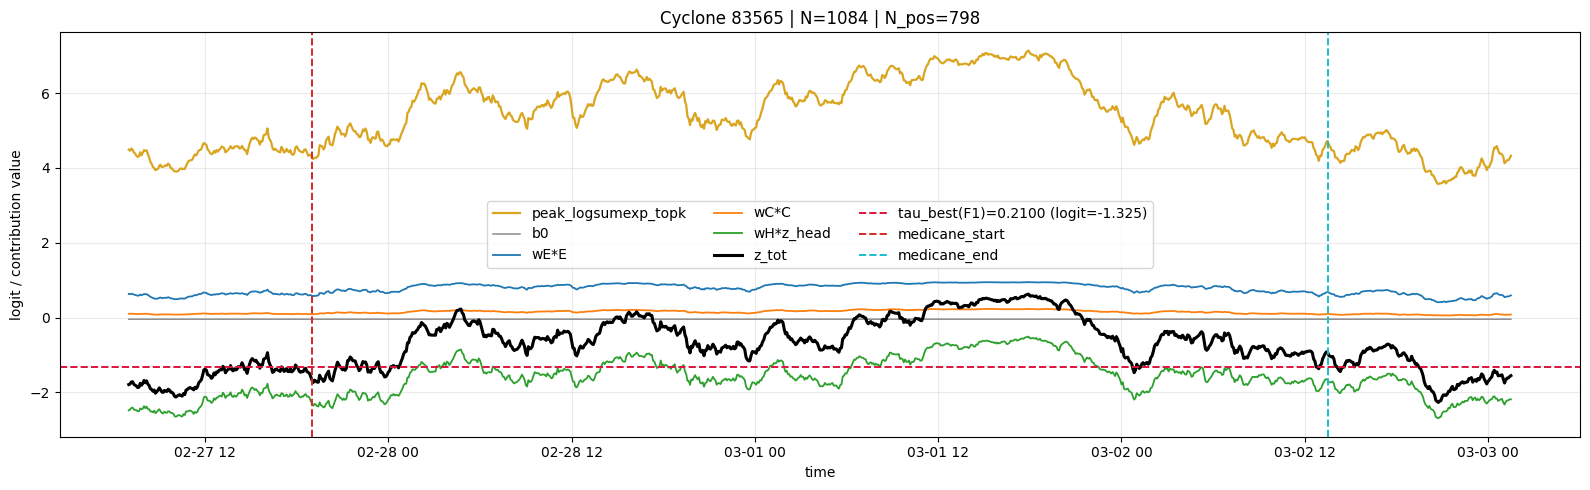

[INFO] saved 1 plot(s) in /media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/plots_per_cyclone
 - /media/isacDisk1/Demetra/moduli/firstpass/outputs/notebook_per_cyclone_threshold/plots_per_cyclone/cyclone_83565_energy_terms.png


In [43]:
# Cell 4: risultati (tabella soglia + plot finale termini energy)
manifest_df = load_manifest(manifest_for_analysis)
manifest_df['presence_gt_prob'] = compute_presence_gt_prob(
    manifest_df,
    temporal_T=temporal_T,
    temporal_stride=temporal_stride,
)

preds_df = load_preds(preds_path)
if 'presence_prob' not in preds_df.columns:
    raise ValueError('Predictions CSV missing presence_prob (required for energy mode analysis)')

joined = preds_df.merge(manifest_df, on='image_path', how='inner', suffixes=('', '_gt'))
if joined.empty:
    raise RuntimeError('No join rows between preds and manifest')

id_col = detect_id_col(joined, forced=ID_COL)
joined = joined.copy()
joined['_cyclone_id'] = joined[id_col].apply(normalize_event_id)
joined = joined[joined['_cyclone_id'].notna()].reset_index(drop=True)
if joined.empty:
    raise RuntimeError(f'No valid cyclone ids in column {id_col}')

# Usiamo sempre presence_prob (z_tot in mode energy)
joined['y_true'] = (pd.to_numeric(joined['presence_gt_prob'], errors='coerce').fillna(0.0) >= 0.5).astype(int)
joined['y_score'] = pd.to_numeric(joined['presence_prob'], errors='coerce')

summary_df = threshold_table_per_cyclone(
    joined=joined,
    id_col=id_col,
    num_thresholds=int(NUM_THRESHOLDS),
    min_samples=int(MIN_SAMPLES),
    tau_used=float(tau_used) if tau_used is not None else None,
)

if summary_df.empty:
    raise RuntimeError('No threshold rows computed (check classes/ids/scores)')

out_table = output_dir / 'threshold_table_by_cyclone.csv'
summary_df.to_csv(out_table, index=False)
print(f'[INFO] saved table -> {out_table}')
with pd.option_context('display.float_format', '{:.3f}'.format):
    display(summary_df)

if str(PRESENCE_MODE).lower().strip() != 'energy':
    raise ValueError('Questo notebook di termini z_tot richiede PRESENCE_MODE="energy"')

terms_df = extract_energy_terms_timeseries(
    cfg_run=cfg_run,
    checkpoint_path=checkpoint_path,
    manifest_path=manifest_for_analysis,
    temporal_T=temporal_T,
    temporal_stride=temporal_stride,
    batch_size=int(BATCH_SIZE),
    num_workers=int(NUM_WORKERS),
    device=DEVICE,
)
if terms_df.empty:
    raise RuntimeError('Nessun termine energy estratto dal manifest')

plot_df = terms_df.merge(
    joined[['image_path', '_cyclone_id', 'y_true', 'y_score', 'presence_gt_prob']].drop_duplicates('image_path'),
    on='image_path',
    how='left',
)
plot_df = plot_df[plot_df['_cyclone_id'].notna()].copy()
if plot_df.empty:
    raise RuntimeError('Nessun dato disponibile per i plot per-ciclone')

terms_csv = output_dir / 'per_clip_energy_terms.csv'
plot_df.to_csv(terms_csv, index=False)
print(f'[INFO] saved energy terms -> {terms_csv}')

boundaries_map = load_windows_boundaries(windows_csv_path)
print(f'[INFO] loaded medicane windows for {len(boundaries_map)} cyclone id(s) from {windows_csv_path}')

plots_dir = output_dir / 'plots_per_cyclone'
plot_paths = plot_terms_by_cyclone(
    plot_df=plot_df,
    summary_df=summary_df,
    output_dir=plots_dir,
    boundaries_map=boundaries_map,
)
print(f'[INFO] saved {len(plot_paths)} plot(s) in {plots_dir}')
for p in plot_paths:
    print(' -', p)





### soglie trovate

In [44]:
d_res = {7001702: 0.300, 7001283: 0.335, 7001328: 0.515, 7001358: 0.255, 7001421: 0.465, 7001461: 0.190, 7001466: 0.335, 
         7001500: 0.435, 7001521: 0.395, 7001542: 0.560, 7001575: 0.635, 7001674: 0.430, 7001715: 0.060, 7001716: 0.065,
         39299: 0.090, 82258: 0.125, 46218: 0.245, 83565: 0.210}
len(d_res)

18